In [3]:
import pandas as pd
import numpy as np
import re
import os
from datetime import datetime, timedelta

# 1. THE FUNCTION (The part we missed!) 🧠
def clean_mechanic_note(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # Remove machine numbers
    # Expand jargon
    jargon_map = {"hydr": "hydraulic", "repl": "replace", "vibr": "vibration", "noisy": "noise"}
    for short, full in jargon_map.items():
        text = text.replace(short, full)
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text.strip()

# 2. GENERATE SYNTHETIC DATA 🏭
templates = {
    "Hydraulic": ["hydr leak on joint", "piston pressure low", "seal repl in hydr system"],
    "Electrical": ["blown fuse in panel B", "wiring frayed on motor", "short circuit detected"],
    "Mechanical": ["vibr in main drive", "bearing noisy", "gearbox metal shavings found"],
    "Noise": ["routine inspection", "cleaned workstation", "discussed with shift lead"]
}

data = []
start_date = datetime(2024, 1, 1)
for i in range(500):
    date = start_date + timedelta(days=np.random.randint(0, 28))
    category = np.random.choice(list(templates.keys()), p=[0.2, 0.2, 0.2, 0.4])
    note = np.random.choice(templates[category])
    data.append({"timestamp": date, "note": note, "actual_cat": category})

df = pd.DataFrame(data).sort_values("timestamp")

# 3. APPLY CLEANING & SAVE 💾
if not os.path.exists('data'):
    os.makedirs('data')

df['clean_note'] = df['note'].apply(clean_mechanic_note)

df.to_csv('data/raw_repair_logs.csv', index=False)
df.to_csv('data/processed_repair_logs.csv', index=False)

print("✅ Function defined, Data cleaned, and CSVs saved successfully!")
print(f"Sample clean note: '{df['clean_note'].iloc[0]}'")

✅ Function defined, Data cleaned, and CSVs saved successfully!
Sample clean note: 'cleaned workstation'


In [5]:
df.head()

,timestamp,note,actual_cat,clean_note
274,2024-01-01,cleaned workstation,Noise,cleaned workstation
1,2024-01-01,gearbox metal shavings found,Mechanical,gearbox metal shavings found
496,2024-01-01,discussed with shift lead,Noise,discussed with shift lead
393,2024-01-01,discussed with shift lead,Noise,discussed with shift lead
381,2024-01-01,discussed with shift lead,Noise,discussed with shift lead


In [6]:
df.isnull().sum()

timestamp     0
note          0
actual_cat    0
clean_note    0
dtype: int64

In [7]:
df.shape

(500, 4)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize Vectorizer
# ngram_range=(1, 2) catches "hydraulic leak" as a single unit
vectorizer = TfidfVectorizer(
    stop_words='english', 
    ngram_range=(1, 2), 
    min_df=2  # Word must appear at least twice to be a 'pattern'
)

# 2. Transform the cleaned notes
X = vectorizer.fit_transform(df['clean_note'])

print(f"📐 Feature Matrix Created! Shape: {X.shape}")
print(f"Top 5 terms: {vectorizer.get_feature_names_out()[:5]}")

📐 Feature Matrix Created! Shape: (500, 53)
Top 5 terms: ['bearing' 'bearing noise' 'blown' 'blown fuse' 'circuit']


In [8]:
%pip install hdbscan

   ---------------------------------------- 0.0/671.7 kB ? eta -:--:--
   ---------------------------------------- 671.7/671.7 kB 8.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import hdbscan

# min_cluster_size: The smallest group of logs we want to call a "failure mode"
# We'll set it to 5 for our small synthetic dataset
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    metric='euclidean', 
    cluster_selection_method='eom' # 'Excess of Mass' - finds the most stable clusters
)

In [10]:
df['cluster_id'] = clusterer.fit_predict(X.toarray())

In [11]:
n_clusters = len(set(df['cluster_id'])) - (1 if -1 in df['cluster_id'] else 0)
n_noise = list(df['cluster_id']).count(-1)

print(f"✅ Found {n_clusters} distinct failure modes!")
print(f"🔍 Identified {n_noise} logs as 'Noise' (unrelated issues).")

✅ Found 12 distinct failure modes!
🔍 Identified 0 logs as 'Noise' (unrelated issues).


In [12]:
# Check what's inside Cluster 0
print("Sample logs from Cluster 0:")
print(df[df['cluster_id'] == 0]['note'].head(5))

Sample logs from Cluster 0:
440    piston pressure low
403    piston pressure low
52     piston pressure low
317    piston pressure low
143    piston pressure low
Name: note, dtype: str


In [15]:
import yake

# 1. Initialize YAKE
kw_extractor = yake.KeywordExtractor(lan="en", n=2, dedupLim=0.9, top=3)

def get_cluster_keywords(cluster_id):
    # Combine all notes in this cluster into one big text block
    combined_text = " ".join(df[df['cluster_id'] == cluster_id]['clean_note'])
    keywords = kw_extractor.extract_keywords(combined_text)
    # Return just the text of the keywords
    return [kw[0] for kw in keywords]

# 2. Map keywords to our clusters
cluster_summary = {}
unique_clusters = sorted(df['cluster_id'].unique())

for cid in unique_clusters:
    if cid == -1:
        cluster_summary[cid] = ["Noise/Uncategorized"]
    else:
        cluster_summary[cid] = get_cluster_keywords(cid)

# 3. Display the "Engineer's Dashboard"
for cid, tags in cluster_summary.items():
    print(f"ID {cid}: {', '.join(tags)}")

ID 0: piston pressure, pressure low, low piston
ID 1: wiring frayed, motor wiring, frayed
ID 2: routine inspection, inspection routine, routine
ID 3: metal shavings, gearbox metal, shavings found
ID 4: shift lead, lead discussed, shift
ID 5: bearing noise, noise bearing, bearing
ID 6: short circuit, circuit detected, detected short
ID 7: seal replace, hydraulic system, system seal
ID 8: hydraulic leak, joint hydraulic, leak
ID 9: blown fuse, fuse, panel
ID 10: main drive, drive vibration, main
ID 11: cleaned workstation, workstation cleaned, cleaned


In [21]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,       # Increase this! Groups must be larger to count.
    min_samples=2,             # How 'conservative' the clustering is.
    prediction_data=True
)
df['cluster_id'] = clusterer.fit_predict(X.toarray())

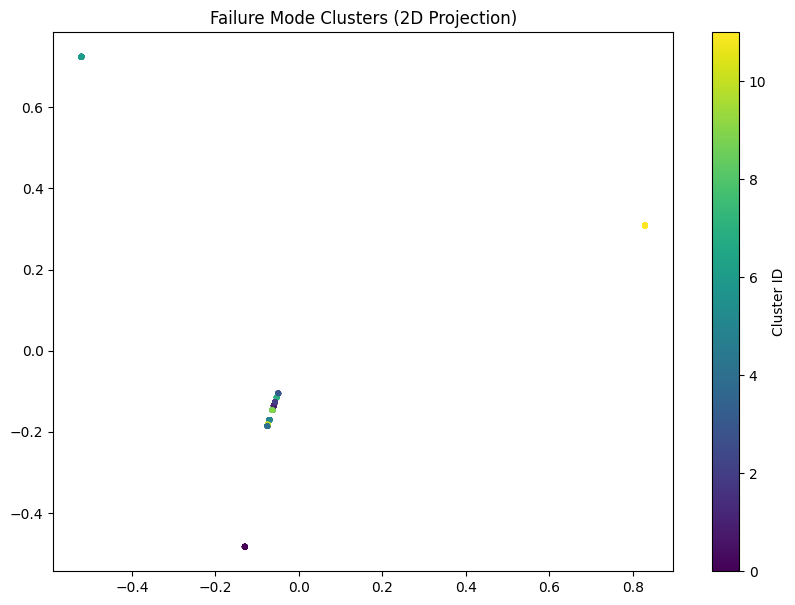

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster_id'], cmap='viridis', s=10)
plt.title("Failure Mode Clusters (2D Projection)")
plt.colorbar(label='Cluster ID')
plt.show()

In [23]:
# Add a "New" problem that only appears at the end of the timeline
drift_logs = [
    {"timestamp": datetime(2024, 1, 27), "note": "overheating sensor error", "actual_cat": "Drift"},
    {"timestamp": datetime(2024, 1, 28), "note": "thermal sensor high temp", "actual_cat": "Drift"},
    {"timestamp": datetime(2024, 1, 28), "note": "overheating detected in unit", "actual_cat": "Drift"}
]

df_drift = pd.concat([df, pd.DataFrame(drift_logs)], ignore_index=True)
df_drift['clean_note'] = df_drift['note'].apply(clean_mechanic_note)

In [19]:
# Vectorize the new combined data
X_new = vectorizer.transform(df_drift['clean_note'])

# Re-run HDBSCAN (or use approximate_predict for real-time)
df_drift['new_cluster_id'] = clusterer.fit_predict(X_new.toarray())

# Logic: Find IDs that didn't exist in the first batch
old_clusters = set(df['cluster_id'].unique())
new_clusters = set(df_drift['new_cluster_id'].unique())
drift_ids = new_clusters - old_clusters - {-1}

if drift_ids:
    print(f"🚨 ALERT: {len(drift_ids)} New Failure Mode(s) Detected!")
    for d_id in drift_ids:
        tags = kw_extractor.extract_keywords(" ".join(df_drift[df_drift['new_cluster_id'] == d_id]['clean_note']))
        print(f"New Mode {d_id} Keywords: {[t[0] for t in tags[:2]]}")
else:
    print("✅ No new drift detected.")

✅ No new drift detected.


In [24]:
# 1. Inject more 'Drift' logs to hit the density threshold
more_drift = [
    {"timestamp": datetime(2024, 1, 28), "note": "overheating sensor high", "actual_cat": "Drift"} 
    for _ in range(12) # Adding 12 logs to be safe
]

df_drift_final = pd.concat([df, pd.DataFrame(more_drift)], ignore_index=True)
df_drift_final['clean_note'] = df_drift_final['note'].apply(clean_mechanic_note)

# 2. Re-vectorize and Re-cluster
X_final = vectorizer.transform(df_drift_final['clean_note'])
df_drift_final['new_cluster_id'] = clusterer.fit_predict(X_final.toarray())

# 3. Check for the new ID
old_ids = set(df['cluster_id'].unique())
new_ids = set(df_drift_final['new_cluster_id'].unique())
detected = new_ids - old_ids - {-1}

if detected:
    print(f"🚨 ALERT: New Failure Mode Detected! Cluster ID: {detected}")
    # Extract keywords for the new mode
    for d_id in detected:
        text = " ".join(df_drift_final[df_drift_final['new_cluster_id'] == d_id]['clean_note'])
        print(f"🔍 Identity of Drift: {kw_extractor.extract_keywords(text)[0][0]}")
else:
    print("❌ Still no drift. Try lowering 'min_cluster_size' in the HDBSCAN settings!")

🚨 ALERT: New Failure Mode Detected! Cluster ID: {np.int64(12)}
🔍 Identity of Drift: overheating sensor
